In [1]:
import torch

In [2]:
import os
import urllib.request

file_path = "hp7.txt"

with open(file_path, "r", encoding="utf-8") as file:
        text_data = file.read()

In [3]:
import tiktoken

tokenizer = tiktoken.get_encoding("gpt2")

In [4]:
print(text_data[:99])

The two men appeared out of nowhere, a few yards apart in the narrow, moonlit 
lane. For a second t


In [5]:
print(text_data[-99:])

demort softly, and the great snake swayed and slithered 
from his shoulders onto the polished wood.


In [6]:
total_char = len(text_data)
total_tokens = len(tokenizer.encode(text_data))

print("Char: ", total_char)
print("Total token: ", total_tokens)

Char:  18323
Total token:  5060


IMPLEMENTING A DATA LOADER
For the efficient data loader implementation, we will use PyTorch's built-in Dataset and DataLoader classes.
Step 1: Tokenize the entire text

Step 2: Use a sliding window to chunk the book into overlapping sequences of max_length

Step 3: Return the total number of rows in the dataset

Step 4: Return a single row from the dataset

In [7]:
from torch.utils.data import Dataset, DataLoader

class GPTDatasetv1(Dataset):
    def __init__(self, txt, tokenizer, max_length, stride):
        self.input_ids = []
        self.target_ids = []

        #tokenize the entire text
        token_ids = tokenizer.encode(txt, allowed_special={"<|endoftext|>"})

        #use a sliding window to chunk the book into overlapping sequences of max length

        for i in range(0, len(token_ids)-max_length, stride):
            input_chunk = token_ids[i:i+max_length]
            target_chunk = token_ids[i+1:i+max_length+1]
            self.input_ids.append(torch.tensor(input_chunk))
            self.target_ids.append(torch.tensor(target_chunk))
        
    def __len__(self):
        return len(self.input_ids)
    
    def __getitem__(self, idx):
        return self.input_ids[idx], self.target_ids[idx]



The following code will use the GPTDatasetV1 to load the inputs in batches via a PyTorch
DataLoader:</div>


    
Step 1: Initialize the tokenizer

Step 2: Create dataset

Step 3: drop_last=True drops the last batch if it is shorter than the specified batch_size to prevent loss spikes
during training

Step 4: The number of CPU processes to use for preprocessing
    
</div>

In [8]:
def create_dataloader_v1(txt, batch_size=4, max_length=256, stride=128, shuffle=True, drop_last=True, num_workers=0):

    #initialize the tokenizer
    tokenizer = tiktoken.get_encoding("gpt2")

    #create dataset
    dataset = GPTDatasetv1(txt, tokenizer, max_length, stride)

    #create dataloader
    dataloader = DataLoader(
        dataset,
        batch_size = batch_size,
        shuffle=shuffle,
        drop_last=drop_last,
        num_workers=num_workers
    )

    return dataloader

With 5,060 tokens, the text is very short for training an LLM, but again, it's for educational purposes (we will also load pretrained weights later).

Next, we divide the dataset into a training and a validation set and use the data loaders from chapter 2 to prepare the batches for LLM training.

For visualization purposes, the figure below assumes a max_length=6, but for the training loader, we set the max_length equal to the context length that the LLM supports.

Since we train the LLM to predict the next word in the text, the targets look the same as these inputs, except that the targets are shifted by one position

In [9]:
class GELU(torch.nn.Module):
    def __init__(self):
        super().__init__()
    
    def forward(self, x):
        return 0.5 * x * (1 + torch.tanh(
            torch.sqrt(torch.tensor(2.0 / torch.pi)) * 
            (x + 0.044715 * torch.pow(x, 3))
        ))

In [10]:
class FeedForward(torch.nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.layers = torch.nn.Sequential(
            torch.nn.Linear(cfg["emb_dim"], 4 * cfg["emb_dim"]),
            GELU(),
            torch.nn.Linear(4 * cfg["emb_dim"], cfg["emb_dim"]),
        )

    def forward(self, x):
        return self.layers(x)

In [11]:
class LayerNorm(torch.nn.Module):
    def __init__(self, emb_dim):
        super().__init__()
        self.eps = 1e-5
        self.scale = torch.nn.Parameter(torch.ones(emb_dim))
        self.shift = torch.nn.Parameter(torch.zeros(emb_dim))

    def forward(self, x):
        mean = x.mean(dim = -1, keepdim=True)
        var = x.var(dim=-1, keepdim=True, unbiased=False)
        norm_x = (x-mean)/torch.sqrt(var+self.eps)
        return self.scale*norm_x + self.shift

In [12]:
class MultiHeadAttention(torch.nn.Module):
    def __init__(self, d_in, d_out, context_length, dropout, num_heads, qkv_bias=False): #d_in is the input embedding size, and d_out is the output embedding size after attention—they can be the same or different depending on the design.
        super().__init__()
        assert (d_out%num_heads==0), "Output dimension must be divisible by number of heads"
        self.d_out = d_out 
        self.num_heads = num_heads
        self.head_dim = d_out//num_heads # each head dimension will have the same number of features. we define the head dim here
        self.W_query = torch.nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_key = torch.nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_value = torch.nn.Linear(d_in, d_out, bias=qkv_bias)
        self.out_proj = torch.nn.Linear(d_out, d_out) #Linear layer to combine the different head outputs
        self.dropout = torch.nn.Dropout(dropout)
        self.register_buffer(
    "mask",
    torch.triu(torch.ones(context_length, context_length), diagonal=1)
)


    def forward(self, x):
        b, num_tokens, d_in = x.shape

        keys=self.W_key(x) #shape = b, num_tokens, d_out
        queries = self.W_query(x)
        values = self.W_value(x)

        # We split the matrix by adding a num_heads dimension
        # unroll the last dimension : (b, num_tokens, d_out) -> (b, num_tokens, num_heads, head_dim)

        keys = keys.view(b, num_tokens, self.num_heads, self.head_dim)
        queries = queries.view(b, num_tokens, self.num_heads, self.head_dim)
        values = values.view(b, num_tokens, self.num_heads, self.head_dim)

        #Transpose
        # (b, num_tokens, num_heads, head_dim) -> (b, num_heads, num_tokens, head_dim)
        keys = keys.transpose(1,2)
        queries = queries.transpose(1,2)
        values = values.transpose(1,2)

        # Compute scaled dot product attention (self attention) using causal mask
        attn_scores = queries @ keys.transpose(2,3) # dot product for each head

         # Original mask truncated to the number of tokens and converted to boolean
        mask_bool = self.mask.bool()[:num_tokens, :num_tokens]

        # Use the mask to fill attention scores
        attn_scores.masked_fill_(mask_bool, -torch.inf)

        attn_weights = torch.softmax(attn_scores / keys.shape[-1]**0.5, dim=-1)
        attn_weights = self.dropout(attn_weights)   

        # Shape: (b, num_tokens, num_heads, head_dim)
        context_vec = (attn_weights @ values).transpose(1, 2) 

        # Combine heads, where self.d_out = self.num_heads * self.head_dim
        context_vec = context_vec.contiguous().view(b, num_tokens, self.d_out)
        context_vec = self.out_proj(context_vec) # optional projection

        return context_vec

In [13]:
class TransformerBlock(torch.nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.att = MultiHeadAttention(
            d_in=cfg["emb_dim"],
            d_out=cfg["emb_dim"],
            context_length=cfg["context_length"],
            num_heads=cfg["n_heads"],
            dropout=cfg["drop_rate"],
            qkv_bias=cfg["qkv_bias"], )
        self.ff = FeedForward(cfg)
        self.norm1 = LayerNorm(cfg["emb_dim"])
        self.norm2 = LayerNorm(cfg["emb_dim"])
        self.drop_shortcut = torch.nn.Dropout(cfg["drop_rate"])

    def forward(self, x):
        #shortcut connection for the attention block
        shortcut = x
        x= self.norm1(x)
        x=self.att(x)
        x = self.drop_shortcut(x)
        x = x+ shortcut # add the original input back

        #shortcut connection for feed forward block
        shortcut = x   
        x = self.norm2(x)
        x = self.ff(x)
        x = self.drop_shortcut(x)
        x = x+shortcut

        return x


In [14]:
class GPTModel(torch.nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.tok_emb = torch.nn.Embedding(cfg["vocab_size"], cfg["emb_dim"])
        self.pos_emb = torch.nn.Embedding(cfg["context_length"], cfg["emb_dim"])
        self.drop_emb = torch.nn.Dropout(cfg["drop_rate"])

        self.trf_blocks = torch.nn.Sequential(
            *[TransformerBlock(cfg) for _ in range(cfg["n_layers"])]
        )
        self.final_norm = LayerNorm(cfg["emb_dim"])
        self.out_head = torch.nn.Linear(
            cfg["emb_dim"], cfg["vocab_size"], bias = False
        )

    def forward(self, in_idx):
        batch_size, seq_len = in_idx.shape
        tok_embeds = self.tok_emb(in_idx)
        pos_embeds = self.pos_emb(torch.arange(seq_len, device = in_idx.device))
        x = tok_embeds + pos_embeds
        x = self.drop_emb(x)
        x = self.trf_blocks(x)
        x = self.final_norm(x)
        logits = self.out_head(x)
        return logits

In [15]:
GPT_CONFIG_124M = {
    "vocab_size": 50257,   # Vocabulary size
    "context_length": 256, # Shortened context length (orig: 1024)
    "emb_dim": 768,        # Embedding dimension
    "n_heads": 12,         # Number of attention heads
    "n_layers": 12,        # Number of layers
    "drop_rate": 0.1,      # Dropout rate
    "qkv_bias": False      # Query-key-value bias
}

In [16]:
# training validation ratio

train_ratio = 0.9
split_idx = int(train_ratio*len(text_data))
train_data = text_data[:split_idx]
val_data = text_data[split_idx:]

torch.manual_seed(123)

train_loader = create_dataloader_v1(
    train_data,
    batch_size=2,
    max_length=GPT_CONFIG_124M["context_length"],
    stride = GPT_CONFIG_124M["context_length"],
    drop_last= True,
    shuffle=True,
    num_workers=0

)

val_loader = create_dataloader_v1(
    val_data,
    batch_size=2,
    max_length=GPT_CONFIG_124M["context_length"],
    stride = GPT_CONFIG_124M["context_length"],
    drop_last= False,
    shuffle=False,
    num_workers=0

)

In [17]:
#sanity check

if total_tokens * (train_ratio) < GPT_CONFIG_124M["context_length"]:
    print("Not enough tokens for the training loader. "
          "Try to lower the `GPT_CONFIG_124M['context_length']` or "
          "increase the `training_ratio`")

if total_tokens * (1-train_ratio) < GPT_CONFIG_124M["context_length"]:
    print("Not enough tokens for the validation loader. "
          "Try to lower the `GPT_CONFIG_124M['context_length']` or "
          "decrease the `training_ratio`")

In [18]:
print("Train loader:")
for x, y in train_loader:
    print(x.shape, y.shape)

print("\nValidation loader:")
for x, y in val_loader:
    print(x.shape, y.shape)

print(len(train_loader))
print(len(val_loader))

Train loader:
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])

Validation loader:
torch.Size([1, 256]) torch.Size([1, 256])
8
1


In [19]:
train_tokens = 0
for input_batch, target_batch in train_loader:
    train_tokens += input_batch.numel()

val_tokens = 0
for input_batch, target_batch in val_loader:
    val_tokens += input_batch.numel()

print("Training tokens:", train_tokens)
print("Validation tokens:", val_tokens)
print("All tokens:", train_tokens + val_tokens)

Training tokens: 4096
Validation tokens: 256
All tokens: 4352


Next, we implement a utility function to calculate the cross-entropy loss of a given batch.

In addition, we implement a second utility function to compute the loss for a user-specified number of batches in a data loader.




In [20]:
def calc_loss_batch(input_batch, target_batch, model, device):
    input_batch, target_batch = input_batch.to(device), target_batch.to(device)
    logits = model(input_batch)
    loss = torch.nn.functional.cross_entropy(logits.flatten(0,1), target_batch.flatten())
    return loss

def calc_loss_loader(data_loader, model, device, num_batches=None):
    total_loss = 0
    if len(data_loader) == 0:
        return float("nan")
    elif num_batches is None:
        num_batches = len(data_loader)
    else:
        # reduce the number of batches to match the total number of batches in the data loader
        # if num batches exceeds the number of batches in the data loader

        num_batches = min(num_batches, len(data_loader))
    
    for i, (input_batch, target_batch) in enumerate(data_loader):
        if i < num_batches:
            loss = calc_loss_batch(input_batch, target_batch, model, device)
            total_loss += loss.item()
        else:
            break
    return total_loss/num_batches

In [21]:
model = GPTModel(GPT_CONFIG_124M)

GENERATING TEXT FROM OUTPUT TOKENS

In [22]:
def generate_text_simple(model, idx, max_new_tokens, context_size):
    # idx is (batch, n_tokens) array of indices in the current context

    ###Input batch:
 ###tensor([[6109, 3626, 6100,  345],
        ##[6109, 1110, 6622,  257]])
    
    for _ in range(max_new_tokens):
        
        # Crop current context if it exceeds the supported context size
        # E.g., if LLM supports only 5 tokens, and the context size is 10
        # then only the last 5 tokens are used as context
        idx_cond = idx[:, -context_size:]
        
        # Get the predictions
        with torch.no_grad():
            logits = model(idx_cond) ### batch, n_tokens, vocab_size
        
        # Focus only on the last time step
        # (batch, n_tokens, vocab_size) becomes (batch, vocab_size)
        logits = logits[:, -1, :]  

        # Apply softmax to get probabilities
        probas = torch.softmax(logits, dim=-1)  # (batch, vocab_size)

        # Get the idx of the vocab entry with the highest probability value
        idx_next = torch.argmax(probas, dim=-1, keepdim=True)  # (batch, 1)

        # Append sampled index to the running sequence
        idx = torch.cat((idx, idx_next), dim=1)  # (batch, n_tokens+1)

    return idx

In [23]:
def text_to_token_ids(text, tokenizer):
    encoded = tokenizer.encode(text, allowed_special={'<|endoftext|>'})
    encoded_tensor = torch.tensor(encoded).unsqueeze(0) # add batch dimension
    return encoded_tensor

def token_ids_to_text(token_ids, tokenizer):
    flat = token_ids.squeeze(0) # remove batch dimension
    return tokenizer.decode(flat.tolist())

TRAINING LOOP FOR THE LLM

In [24]:
def train_model_simple(model, train_loader, val_loader, optimizer, device, num_epochs, 
                       eval_freq, eval_iter, start_context, tokenizer):
    # initialize lists to track losses and tokens seen
    train_losses, val_losses, track_tokens_seen = [], [], []
    tokens_seen, global_step = 0, -1

    # main training loop
    for epoch in range(num_epochs):
        model.train() # set model to train mode (earlier we did eval mode)

        for input_batch, target_batch in train_loader:
            optimizer.zero_grad() # reset loss gradients from prev batch iteration
            loss = calc_loss_batch(input_batch, target_batch, model, device)
            loss.backward() # calculate loss gradients
            optimizer.step() # update model weights using loss gradients
            tokens_seen += input_batch.numel() # returns total number of elements or tokens in the input batch
            global_step += 1

            #optional evaluation step
            
            if global_step%eval_freq ==0:
                train_loss, val_loss = evaluate_model(
                    model, train_loader, val_loader, device, eval_iter)
                train_losses.append(train_loss)
                val_losses.append(val_loss)
                track_tokens_seen.append(tokens_seen)
                print(f"Ep {epoch+1} (Step {global_step:06d})"
                      f"Train loss {train_loss:.3f}, val loss {val_loss: .3f}")
            
        #print sample text after each epoch
        generate_and_print_sample(
            model, tokenizer, device, start_context
        )
    return train_losses, val_losses, track_tokens_seen




Step 1: Initialize lists to track losses and tokens seen

Step 2: Start the main training loop

Step 3: Reset loss gradients from previous batch iteration

Step 4: Calculate loss gradients

Step 5: Update model weights using loss gradients

Step 6: Optional evaluation step

Step 7: Print a sample text after each epoch

In [25]:
def evaluate_model(model, train_loader, val_loader, device, eval_iter):
    model.eval()
    with torch.no_grad():
        train_loss = calc_loss_loader(train_loader, model, device, num_batches=eval_iter)
        val_loss = calc_loss_loader(val_loader, model, device, num_batches=eval_iter)
    model.train()
    return train_loss, val_loss


The evaluate_model function calculates the loss over the training and validation set while ensuring the model is in evaluation mode with gradient tracking and dropout disabled when calculating the loss over the training and validation sets

In [26]:
def generate_and_print_sample(model, tokenizer, device, start_context):
    model.eval()
    context_size = model.pos_emb.weight.shape[0]
    encoded = text_to_token_ids(start_context, tokenizer).to(device)
    with torch.no_grad():
        token_ids = generate_text_simple(
            model = model, idx = encoded, max_new_tokens= 50, context_size=context_size
        )
    decoded_text = token_ids_to_text(token_ids, tokenizer)
    print(decoded_text.replace("\n", " "))
    model.train()
    

The generate_and_print_sample function is a convenience function that we use to track whether the model improves during the training.

In particular, the generate_and_print_sample function takes a text snippet (start_context) as input, converts it into token IDs, and feeds it to the LLM to generate a text sample using the generate_text_simple function we used earlier

Let's see this all in action by training a GPTModel instance for 10 epochs using an AdamW optimizer and the train_model_simple function we defined earlier.

In [27]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [30]:
import time
start_time = time.time()

torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_124M)
model.to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr = 0.0004, weight_decay=0.1)

num_epochs = 10
train_losses, val_losses, tokens_seen = train_model_simple(
    model, train_loader, val_loader, optimizer, device, num_epochs=num_epochs, eval_freq=5, eval_iter=5,
    start_context="Every effort moves you", tokenizer=tokenizer
)

end_time = time.time()
execution_time = (end_time-start_time)/60
print(f"Training completed in {execution_time:.2f} minutes")

Ep 1 (Step 000000)Train loss 9.163, val loss  9.276
Ep 1 (Step 000005)Train loss 7.072, val loss  7.786
Every effort moves you,”  ”  ”  ”  ”  ”  ”  ”  ”  ”  ”  ”  �
Ep 2 (Step 000010)Train loss 6.049, val loss  7.018
Ep 2 (Step 000015)Train loss 4.867, val loss  6.839
Every effort moves you,”  ”  ”  ”  ”  ”  ”  ”  ”  ”  ”  ”  �
Ep 3 (Step 000020)Train loss 4.890, val loss  6.980
Every effort moves you to  ”  ”  ”  ”  ”  ”  ”  ”  ”  ”  ”  ” 
Ep 4 (Step 000025)Train loss 4.142, val loss  6.925
Ep 4 (Step 000030)Train loss 3.578, val loss  6.854
Every effort moves you to be  “I, and of the table,  “I,  “I”  “I his.”  “I,“I.  “I
Ep 5 (Step 000035)Train loss 2.939, val loss  6.961
Every effort moves you to  “I, the Order of the  ”  “I have been,“I,”  ”  ”  “I in the Ministry.  “
Ep 6 (Step 000040)Train loss 2.198, val loss  6.976
Ep 6 (Step 000045)Train loss 1.977, val loss  7.050
Every effort moves you  “My Lord, the Order of the table.”  “I have been, with their vertical.“I have been  “I 

DECODING STRATEGIES TO CONTROL RANDOMNESS

First, we briefly revisit the generate_text_simple function from the previous chapter that we used inside the generate_and_print_sample earlier in this chapter.

Then, we will cover two techniques, temperature scaling, and top-k sampling, to improve this function.

We begin by transferring the model back from the GPU to the CPU since inference with a relatively small model does not require a GPU. Also, after training, we put the model into evaluation model to turn off random components such as dropout:

In [31]:
model.to("cpu")
model.eval()


GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(256, 768)
  (drop_emb): Dropout(p=0.1, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=False)
        (W_key): Linear(in_features=768, out_features=768, bias=False)
        (W_value): Linear(in_features=768, out_features=768, bias=False)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.1, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features

Next, we plug the GPTModel instance (model) into the generate_text_simple function, which uses the LLM to generate one token at a time:

In [32]:
tokenizer = tiktoken.get_encoding("gpt2")

token_ids = generate_text_simple(
    model=model,
    idx=text_to_token_ids("Every effort moves you", tokenizer),
    max_new_tokens=25,
    context_size=GPT_CONFIG_124M["context_length"]
)

print("Output text:\n", token_ids_to_text(token_ids, tokenizer))

Output text:
 Every effort moves you before he has been no higher 
pleasure.” 
” 
” 
“


DECODING STRATEGY 1: TEMPERATURE SCALING

Previously, inside the generate_text_simple function, we always sampled the token with the highest probability as the next token using torch.argmax, also known as greedy decoding.

To generate text with more variety, we can replace the argmax with a function that samples from a probability distribution (here, the probability scores the LLM generates for each vocabulary entry at each token generation step).

To illustrate the probabilistic sampling with a concrete example, let's briefly discuss the next-token generation process using a very small vocabulary for illustration purposes:

In [33]:
vocab = { 
    "closer": 0,
    "every": 1, 
    "effort": 2, 
    "forward": 3,
    "inches": 4,
    "moves": 5, 
    "pizza": 6,
    "toward": 7,
    "you": 8,
} 

inverse_vocab = {v: k for k, v in vocab.items()}

Next, assume the LLM is given the start context "every effort moves you" and generates the following next-token logits:

In [34]:
next_token_logits = torch.tensor(
[4.51, 0.89, -1.90, 6.75, 1.63, -1.62, -1.89, 6.28, 1.79]
)

next_token_logits2 = next_token_logits/0.1

next_token_logits3 = next_token_logits/5

As discussed in the previous chapter, inside the generate_text_simple, we convert the logits into probabilities via the softmax function and obtain the token ID corresponding the generated token via the argmax function, which we can then map back into text via the inverse vocabulary:

In [36]:
torch.set_printoptions(sci_mode=False)

In [37]:
probas = torch.softmax(next_token_logits2, dim=0)

print(probas)

tensor([    0.0000,     0.0000,     0.0000,     0.9910,     0.0000,     0.0000,
            0.0000,     0.0090,     0.0000])


In [38]:
probas = torch.softmax(next_token_logits3, dim=0)

print(probas)

tensor([0.1546, 0.0750, 0.0429, 0.2421, 0.0869, 0.0454, 0.0430, 0.2203, 0.0898])


In [39]:
probas = torch.softmax(next_token_logits, dim=0)

print(probas)

next_token_id = torch.argmax(probas).item()

print(next_token_id)

print(inverse_vocab[next_token_id])

tensor([    0.0609,     0.0016,     0.0001,     0.5721,     0.0034,     0.0001,
            0.0001,     0.3576,     0.0040])
3
forward


To implement a probabilistic sampling process, we can now replace the argmax with the multinomial function in PyTorch:

In [45]:
torch.manual_seed(123)
next_token_id = torch.multinomial(probas, num_samples=1).item()
print(inverse_vocab[next_token_id])

toward


The printed output is "forward" just like before. What happened? The multinomial function samples the next token proportional to its probability score.

In other words, "forward" is still the most likely token and will be selected by multinomial most of the time but not all the time.

To illustrate this, let's implement a function that repeats this sampling 1000 times:

In [50]:
def print_sampled_tokens(probas):
    torch.manual_seed(123)
    sample = [torch.multinomial(probas, num_samples=1).item() for i in range(1_000)]
    sampled_ids = torch.bincount(torch.tensor(sample))
    for i, freq in enumerate(sampled_ids):
        print(f"{freq} x {inverse_vocab[i]}")
    
print_sampled_tokens(probas)


71 x closer
2 x every
0 x effort
544 x forward
2 x inches
1 x moves
0 x pizza
376 x toward
4 x you


As we can see based on the output, the word "forward" is sampled most of the time (544 out of 1000 times), but other tokens such as "closer", "inches", and "toward" will also be sampled some of the time.

This means that if we replaced the argmax function with the multinomial function inside the generate_and_print_sample function, the LLM would sometimes generate texts such as "every effort moves you toward", "every effort moves you inches", and "every effort moves you closer" instead of "every effort moves you forward".

We can further control the distribution and selection process via a concept called temperature scaling, where temperature scaling is just a fancy description for dividing the logits by a number greater than 0:

=Temperatures greater than 1 result in more uniformly distributed token probabilities,
and Temperatures smaller than 1 will result in more confident (sharper or more peaky)
distributions.

Let's illustrate this by plotting the original probabilities alongside
probabilities scaled with different temperature values:

In [52]:
def softmax_with_temperature(logits, temperature):
    scaled_logits = logits/temperature
    return torch.softmax(scaled_logits, dim=0)

#temperature values
temperatures = [1, 0.1, 5]

#calculate scaled probabilities
scaled_probas = [softmax_with_temperature(next_token_logits, T) for T in temperatures]

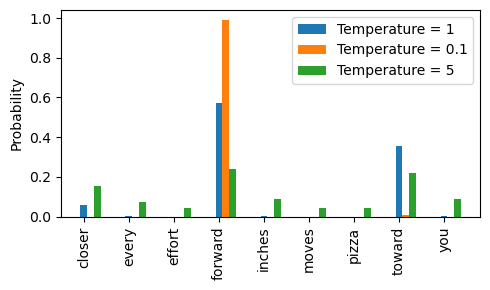

In [53]:
import matplotlib.pyplot as plt
# Plotting
x = torch.arange(len(vocab))
bar_width = 0.15

fig, ax = plt.subplots(figsize=(5, 3))
for i, T in enumerate(temperatures):
    rects = ax.bar(x + i * bar_width, scaled_probas[i], bar_width, label=f'Temperature = {T}')

ax.set_ylabel('Probability')
ax.set_xticks(x)
ax.set_xticklabels(vocab.keys(), rotation=90)
ax.legend()

plt.tight_layout()
plt.savefig("temperature-plot.pdf")
plt.show()



A temperature of 1 divides the logits by 1 before passing them to the softmax function to
compute the probability scores. 

In other words, using a temperature of 1 is the same as not
using any temperature scaling. 

In this case, the tokens are selected with a probability equal
to the original softmax probability scores via the multinomial sampling function in PyTorch.    


Applying very small temperatures, such as 0.1, will
result in sharper distributions such that the behavior of the multinomial function selects
the most likely token (here: "forward") almost 100% of the time, approaching the
behavior of the argmax function. 

Vice versa, a temperature of 5 results in a more uniform
distribution where other tokens are selected more often. 

This can add more variety to the
generated texts but also more often results in nonsensical text. 

For example, using the
temperature of 5 results in texts such as "every effort moves you pizza" about 4% of
the time.
 

DECODING STRATEGY 2: Top K Sampling


In the previous section, we implemented a probabilistic sampling approach coupled with
temperature scaling to increase the diversity of the outputs. 

We saw that higher
temperature values result in more uniformly distributed next-token probabilities, which
result in more diverse outputs as it reduces the likelihood of the model repeatedly selecting
the most probable token. 

This method allows for exploring less likely but potentially more
interesting and creative paths in the generation process. 

However, One downside of this
approach is that it sometimes leads to grammatically incorrect or completely nonsensical
outputs such as "every effort moves you pizza".


In this section, we introduce another concept called top-k sampling, which, when
combined with probabilistic sampling and temperature scaling, can improve the text
generation results.

In top-k sampling, we can restrict the sampled tokens to the top-k most likely tokens
and exclude all other tokens from the selection process by masking their probability scores.


In [54]:
top_k = 3
top_logits, top_pos = torch.topk(next_token_logits, top_k)
print("Top Logits: ", top_logits)
print("Top pos: ", top_pos)

Top Logits:  tensor([6.7500, 6.2800, 4.5100])
Top pos:  tensor([3, 7, 0])


Subsequently, we apply PyTorch's where function to set the logit values of tokens that are below the lowest logit value within our top-3 selection to negative infinity (-inf).

In [55]:
new_logits = torch.where(
    condition=next_token_logits < top_logits[-1],
    input=torch.tensor(float("-inf")),
    other=next_token_logits
)

print(new_logits)

tensor([4.5100,   -inf,   -inf, 6.7500,   -inf,   -inf,   -inf, 6.2800,   -inf])


Lastly, let's apply the softmax function to turn these into next-token probabilities:

In [56]:
top_k_probas = torch.softmax(new_logits, dim=0)
print(top_k_probas)

tensor([0.0615, 0.0000, 0.0000, 0.5775, 0.0000, 0.0000, 0.0000, 0.3610, 0.0000])


MERGE TEMPERATURE SCALING AND TOP K SAMPLING

We can now apply the temperature scaling and multinomial function for probabilistic
sampling introduced in the previous section to select the next token among these 3 nonzero probability scores to generate the next token. We do this in the next section by
modifying the text generation function.


The previous two subsections introduced two concepts to increase the diversity of LLMgenerated text: temperature sampling and top-k sampling. In this section, we combine and
add these concepts to modify the generate_simple function we used to generate text via
the LLM earlier, creating a new generate function:


Step 1: For-loop is the same as before: Get logits, and only focus on last time step

Step 2: In this new section, we filter logits with top_k sampling

Step 3: This is the new section where we apply temperature scaling
    
Step 4: Carry out greedy next-token selection as before when temperature scaling is disabled

Step 5: Stop generating early if end-of-sequence token is encountered and eos_id is specified

</div>

In [58]:
def generate(model, idx, max_new_tokens, context_size, temperature = 0.0, top_k=None, eos_id=None):

    for _ in range(max_new_tokens):
        idx_cond = idx[:, -context_size:]
        with torch.no_grad():
            logits = model(idx_cond)
        logits = logits[:, -1,:]
    
        #Filter logits with  topk sampling
        if top_k is not None:
            # keep only top k values
            top_logits, _ = torch.topk(logits, top_k)
            min_val = top_logits[:, -1]
            logits = torch.where(logits < min_val, torch.tensor(float("-inf")).to(logits.device), logits)
        
        #Apply temperature scaling
        if temperature > 0.0:
            logits = logits/temperature

            # apply softmax to get probabilities
            probs = torch.softmax(logits, dim=-1)

            # sample from the distribution
            idx_next = torch.multinomial(probs, num_samples=1)
        
        else:
            idx_next = torch.argmax(logits, dim=-1, keepdim=True)
        
        if idx_next == eos_id:
            break

        idx = torch.cat((idx, idx_next), dim=1)

    return idx
